# D2–D5 Targeting Profile

**Purpose:** Identify who the moveable-middle (D2–D5) customers are, and what first-order signals predict progression toward D1 loyalty.

**Structure:**
1. Full Decile Table (2023–2025) — verifies D1–D10 against benchmark values
2. D2–D5 Descriptive Profile — channel, geography, first category, discount, timing, subscription
3. Cox Proportional Hazards Model — what first-order features predict time-to-repeat for all customers
4. D1 Uplift Analysis — logistic regression: what distinguishes D1 vs D2–D5 customers
5. Targeting Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    from lifelines import CoxPHFitter
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print('lifelines not installed — Cox model will be skipped. Run: pip install lifelines')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

BASE_DIR   = Path('..')
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
SILVER_DIR = BASE_DIR / 'medallion' / 'silver'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

PALETTE = {'D1':'#2E86AB','D2':'#4BA3C3','D3':'#68B8D8','D4':'#89CCEC','D5':'#ABE0FF',
           'Others':'#E0E0E0'}
print('Imports OK')

Imports OK


In [2]:
cf  = pd.read_parquet(GOLD_DIR   / 'gold_churn_features.parquet')
co  = pd.read_parquet(GOLD_DIR   / 'gold_customer_orders.parquet')
so  = pd.read_parquet(SILVER_DIR / 'silver_orders.parquet')
pm  = pd.read_parquet(SILVER_DIR / 'silver_products.parquet')

EXCLUDED_B2B_CUSTOMERS = {'7574631284991'}  # 100% Draft Order bulk wholesale account
retail_customers = set(cf['customer_id']) - EXCLUDED_B2B_CUSTOMERS

def group_channel(ch):
    if ch in ('DTC', 'web'): return 'DTC'
    if ch == 'Lazada':       return 'Lazada'
    if ch == 'Shopee':       return 'Shopee'
    return 'Others'

order_channel = co[['order_id', 'channel', 'processed_at']].copy()
order_channel['processed_at']    = pd.to_datetime(order_channel['processed_at'], errors='coerce', utc=True)
order_channel['order_year']      = order_channel['processed_at'].dt.year
order_channel['channel_grouped'] = order_channel['channel'].apply(group_channel)

so_retail = so[so['Customer: ID'].isin(retail_customers)].copy()
so_retail = so_retail.merge(
    order_channel[['order_id', 'channel_grouped', 'order_year']],
    left_on='ID', right_on='order_id', how='inner'
)
so_retail = so_retail[so_retail['Line: Type'] == 'Line Item'].copy()
so_retail['line_revenue'] = so_retail['Line: Price'] * so_retail['Line: Quantity']
so_retail['sku'] = so_retail['Line: SKU'].str.strip().str.upper()

print(f'Retail customers: {len(retail_customers):,}')
print(f'Line items loaded: {len(so_retail):,}')

Retail customers: 12,818
Line items loaded: 48,636


In [3]:
# Barcode → SKU lookup (DTC/Shopee orders often store EAN barcode in Line: SKU)
barcode_to_sku = (
    pm[pm['Variant Barcode'].notna() & pm['Variant SKU'].notna()]
    [['Variant Barcode', 'Variant SKU']]
    .assign(
        barcode_clean = lambda x: x['Variant Barcode'].astype(str).str.strip().str.replace("'", '', regex=False),
        sku_clean     = lambda x: x['Variant SKU'].str.strip().str.upper()
    )
    .drop_duplicates(subset='barcode_clean')
    .set_index('barcode_clean')['sku_clean']
    .to_dict()
)

title_to_sku = (
    pm[pm['Variant SKU'].notna() & pm['Title'].notna()]
    .drop_duplicates(subset='Title')[['Title', 'Variant SKU']]
    .assign(sku_clean = lambda x: x['Variant SKU'].str.strip().str.upper())
    .sort_values(by='Title', key=lambda x: x.str.len(), ascending=False)
    .reset_index(drop=True)
)

def match_pm_title(line_title):
    if pd.isna(line_title): return None
    lt = line_title.lower().strip()
    for _, row in title_to_sku.iterrows():
        if row['Title'].lower().strip() in lt:
            return row['sku_clean']
    return None

def infer_category_from_title(title):
    if pd.isna(title): return None
    title = title.lower()
    if 'lean meal'    in title: return 'LMEAL'
    if 'better whey'  in title and 'elite' not in title: return 'BET'
    if 'clear' in title and 'shaker' not in title and 'clearance' not in title: return 'CLEAR'
    if 'lean' in title and 'clean' not in title: return 'LEAN'
    if 'plant'        in title: return 'PLT'
    if 'collagen'     in title: return 'COL'
    if 'soy'          in title: return 'SOY'
    if 'creatine'     in title: return 'CRE'
    if 'prime whey'   in title: return 'PRI'
    if 'elite'        in title: return 'ELT'
    if any(x in title for x in ['shaker','bottle','hat','shirt','band','sweater','tote','tee']): return 'ACC'
    if any(x in title for x in ['pack','bundle','starter','sampler','variety']): return 'BND'
    if any(x in title for x in ['capsule','omega','l-carnitine','green tea','multivitamin','cla','bcaa']): return 'CAP'
    return None

numeric_pattern = r'^\d+(_\d+)?$'
needs_barcode = (
    so_retail['sku'].isna() | (so_retail['sku'] == '') |
    so_retail['sku'].str.match(numeric_pattern, na=False)
)
so_retail.loc[needs_barcode, 'sku'] = (
    so_retail.loc[needs_barcode, 'Line: SKU'].str.strip().map(barcode_to_sku)
)

still_unresolved = (
    so_retail['sku'].isna() | (so_retail['sku'] == '') |
    so_retail['sku'].str.match(numeric_pattern, na=False)
)
so_retail.loc[still_unresolved, 'sku'] = None

null_sku_mask = so_retail['sku'].isna() | (so_retail['sku'] == '')
so_retail.loc[null_sku_mask, 'sku'] = (
    so_retail.loc[null_sku_mask, 'Line: Title'].apply(match_pm_title)
)

null_sku_mask = so_retail['sku'].isna() | (so_retail['sku'] == '')
so_retail.loc[null_sku_mask, 'sku'] = (
    so_retail.loc[null_sku_mask, 'Line: Title'].apply(infer_category_from_title)
)

n_before = len(so_retail)
so_retail = so_retail[
    so_retail['sku'].notna() & (so_retail['sku'] != '') & so_retail['line_revenue'].notna()
].copy()
print(f'Rows retained: {len(so_retail):,} / {n_before:,}  ({len(so_retail)/n_before:.1%})')

Rows retained: 47,095 / 48,636  (96.8%)


In [4]:
SKU_CATEGORY_MAP = {
    'BET'   : 'Better Whey',
    'LEAN'  : 'Lean Protein',
    'LMEAL' : 'Lean Meal',
    'CLEAR' : 'Clear Protein',
    'ACC'   : 'Accessories',
    'PLT'   : 'Plant Protein',
    'BND'   : 'Bundles',
    'COL'   : 'Collagen',
    'CAP'   : 'Capsules & Supplements',
    'CRE'   : 'Creatine',
    'SOY'   : 'Soy Protein',
    'PRI'   : 'Prime Whey',
    'ELT'   : 'Elite Protein',
}

so_retail['sku_prefix'] = so_retail['sku'].str.split('-').str[0]
so_retail['category']   = so_retail['sku_prefix'].map(SKU_CATEGORY_MAP).fillna('Other')

print('Category breakdown (all years):')
print(so_retail['category'].value_counts().to_string())

Category breakdown (all years):
category
Better Whey               10711
Accessories                5336
Lean Protein               5224
Plant Protein              5082
Clear Protein              4525
Collagen                   3128
Bundles                    2701
Capsules & Supplements     2500
Prime Whey                 1989
Creatine                   1768
Elite Protein              1713
Soy Protein                1529
Lean Meal                   730
Other                       159


In [5]:
so_recent = so_retail[so_retail['order_year'].isin([2023, 2024, 2025])].copy()
print(f'2023-2025 line items: {len(so_recent):,}')

# Cost map from product master
sku_cost_map = (
    pm[pm['Cost per item'].notna()]
    .assign(sku_clean=lambda x: x['Variant SKU'].str.strip().str.upper())
    .set_index('sku_clean')['Cost per item']
    .to_dict()
)

# Bundle cost inference (multi-pack = N × base SKU cost)
bundle_map = {
    'CLEAR-GRA-500G-2BL-V2': ('CLEAR-GRA-500G-V2', 2),
    'CLEAR-GRA-500G-4BL-V2': ('CLEAR-GRA-500G-V2', 4),
    'CLEAR-PEA-500G-2BL-V2': ('CLEAR-PEA-500G-V2', 2),
    'CLEAR-PEA-500G-4BL-V2': ('CLEAR-PEA-500G-V2', 4),
    'COL-UNF-300G-2BL-V1':   ('COL-UNF-300G-V1',  2),
    'COL-UNF-300G-4BL-V1':   ('COL-UNF-300G-V1',  4),
    'CRE-UNF-250G-2BL-V1':   ('CRE-UNF-250G-V1',  2),
    'CRE-UNF-250G-4BL-V1':   ('CRE-UNF-250G-V1',  4),
    'LEAN-TAR-1KG-2BL-V1':   ('LEAN-TAR-1KG-V1',  2),
    'LEAN-TAR-1KG-4BL-V1':   ('LEAN-TAR-1KG-V1',  4),
    'LEAN-THA-1KG-2BL-V1':   ('LEAN-THA-1KG-V1',  2),
    'LEAN-THA-1KG4BL-V1':    ('LEAN-THA-1KG-V1',  4),
    'SOY-UNF-1KG-2BL-V1':    ('SOY-UNF-1KG-V1',   2),
    'SOY-UNF-1KG-4BL-V1':    ('SOY-UNF-1KG-V1',   4),
}
for bundle_sku, (base_sku, mult) in bundle_map.items():
    if base_sku in sku_cost_map and bundle_sku not in sku_cost_map:
        sku_cost_map[bundle_sku] = sku_cost_map[base_sku] * mult

so_recent2 = so_recent.copy()
so_recent2['unit_cost'] = so_recent2['sku'].map(sku_cost_map)
so_recent2['line_cost'] = so_recent2['unit_cost'] * so_recent2['Line: Quantity']

has_cost = so_recent2['line_cost'].notna()
category_margin_proxy = (
    so_recent2[has_cost]
    .groupby('category')
    .apply(lambda g: 1 - g['line_cost'].sum() / g['line_revenue'].sum())
)
overall_margin = (
    1 - so_recent2.loc[has_cost,'line_cost'].sum()
      / so_recent2.loc[has_cost,'line_revenue'].sum()
)

def fill_cost(row):
    if pd.notna(row['line_cost']): return row['line_cost']
    proxy = category_margin_proxy.get(row['category'], overall_margin)
    proxy = overall_margin if pd.isna(proxy) else proxy
    return row['line_revenue'] * (1 - proxy)

so_recent2['line_cost_final'] = so_recent2.apply(fill_cost, axis=1)
so_recent2['gross_profit']    = so_recent2['line_revenue'] - so_recent2['line_cost_final']
print(f'Cost coverage: {has_cost.mean():.1%}')

2023-2025 line items: 20,466
Cost coverage: 97.4%


In [6]:
EXCLUDED_FROM_CUSTOMER_ANALYSIS = {'7888450879743'}  # Guest-checkout placeholder

so_recent_cust = so_recent[~so_recent['Customer: ID'].isin(EXCLUDED_FROM_CUSTOMER_ANALYSIS)]

customer_revenue = (
    so_recent_cust.groupby('Customer: ID')
    .agg(total_revenue=('line_revenue', 'sum'))
    .reset_index()
)

customer_revenue['decile'] = pd.qcut(
    customer_revenue['total_revenue'].rank(method='first', ascending=False),
    10, labels=[f'D{i}' for i in range(1, 11)]
)

print(f'Customers with 2023-2025 activity: {len(customer_revenue):,}')
print(f'Total revenue: SGD {customer_revenue["total_revenue"].sum():,.0f}')
print()
print('Decile revenue summary:')
print(customer_revenue.groupby('decile', observed=True)['total_revenue']
      .agg(['count','mean','sum']).round(0).to_string())

Customers with 2023-2025 activity: 6,316
Total revenue: SGD 1,543,593

Decile revenue summary:
        count    mean       sum
decile                         
D1        632  1404.0  887049.0
D2        632   353.0  223304.0
D3        631   211.0  132883.0
D4        632   142.0   89597.0
D5        631   106.0   66752.0
D6        632    74.0   47078.0
D7        631    61.0   38514.0
D8        632    49.0   30944.0
D9        631    31.0   19512.0
D10       632    13.0    7961.0


In [7]:
# Customer-level stats (n_orders, n_categories, n_skus per customer)
cust_stats = (
    so_recent.groupby('Customer: ID')
    .agg(
        n_orders     =('ID',       'nunique'),
        n_categories =('category', 'nunique'),
        n_skus       =('sku',      'nunique'),
    )
    .reset_index()
)
cust_stats = cust_stats.merge(
    customer_revenue[['Customer: ID','total_revenue','decile']], on='Customer: ID'
)

# Order-level stats (qty, revenue, category count per order)
order_stats = (
    so_recent.groupby(['Customer: ID', 'ID'])
    .agg(
        order_qty    =('Line: Quantity', 'sum'),
        order_revenue=('line_revenue',   'sum'),
        order_n_cats =('category',       'nunique'),
    )
    .reset_index()
)
order_stats = order_stats.merge(
    customer_revenue[['Customer: ID','decile']], on='Customer: ID'
)

total_customers = len(customer_revenue)

decile_summary = []
for d in [f'D{i}' for i in range(1, 11)]:
    cust_d = cust_stats[cust_stats['decile'] == d]
    ord_d  = order_stats[order_stats['decile'] == d]

    n_cust       = len(cust_d)
    avg_revenue  = cust_d['total_revenue'].mean()
    aof          = cust_d['n_orders'].mean()
    total_rev    = cust_d['total_revenue'].sum()
    total_orders = ord_d.shape[0]
    aov          = total_rev / total_orders
    avg_cats     = cust_d['n_categories'].mean()
    avg_prods    = cust_d['n_skus'].mean()
    total_qty    = ord_d['order_qty'].sum()
    units_per_tx = total_qty / total_orders
    per_unit     = total_rev / total_qty
    cats_per_tx  = ord_d['order_n_cats'].mean()
    units_per_cat = units_per_tx / cats_per_tx

    decile_summary.append({
        'Decile': d, '%Cust': n_cust / total_customers,
        'Avg Revenue': avg_revenue, 'AOF': aof, 'AOV': aov,
        'Avg Cats': avg_cats, 'Avg Prods': avg_prods,
        'Units/Tx': units_per_tx, '$/Unit': per_unit,
        'Units/Cat': units_per_cat, 'Cats/Tx': cats_per_tx,
    })

decile_df = pd.DataFrame(decile_summary)

# Add margin from so_recent2
cust_profit = (
    so_recent2.groupby('Customer: ID')
    .agg(total_cost=('line_cost_final','sum'))
    .reset_index()
)
cust_profit = cust_profit.merge(
    customer_revenue[['Customer: ID','total_revenue','decile']], on='Customer: ID'
)
cust_profit['gross_profit'] = cust_profit['total_revenue'] - cust_profit['total_cost']

margin_by_decile = (
    cust_profit.groupby('decile', observed=True)
    .apply(lambda g: pd.Series({
        'Avg Gross Profit': g['gross_profit'].mean(),
        'Margin %': g['gross_profit'].sum() / g['total_revenue'].sum()
    }))
    .reset_index().rename(columns={'decile':'Decile'})
)

decile_df = decile_df.merge(margin_by_decile, on='Decile')

print('Decile Table (2023-2025):')
print(decile_df.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Decile Table (2023-2025):
Decile  %Cust  Avg Revenue  AOF   AOV  Avg Cats  Avg Prods  Units/Tx  $/Unit  Units/Cat  Cats/Tx  Avg Gross Profit  Margin %
    D1    0.1       1403.6  5.7 244.9       3.3        4.4       3.7    66.6        2.4      1.5            1122.3       0.8
    D2    0.1        353.3  2.4 147.4       2.4        3.0       2.4    62.5        1.5      1.5             277.8       0.8
    D3    0.1        210.6  1.8 115.7       2.0        2.5       2.2    53.5        1.4      1.5             161.1       0.8
    D4    0.1        141.8  1.4  99.4       1.9        2.3       2.1    46.8        1.4      1.6             104.2       0.7
    D5    0.1        105.8  1.3  84.3       1.7        2.0       2.1    39.6        1.4      1.5              77.0       0.7
    D6    0.1         74.5  1.1  66.2       1.4        1.6       1.7    39.2        1.3      1.3              55.0       0.7
    D7    0.1         61.0  1.0  58.6       1.2        1.2       1.3    46.9        1.1      1.2   

---
## Part 2 — D2–D5 Descriptive Profile

We merge the 2023–2025 decile assignment with `gold_churn_features` to pull first-order signals:
acquisition channel, country, first product category, discount behaviour, time to second order, and subscription status.

In [8]:
# Merge decile assignment with first-order profile from gold_churn_features
cf_cols = [
    'customer_id', 'acquisition_channel', 'acquisition_country',
    'is_discount_acquired', 'first_order_aov', 'first_order_num_categories',
    'first_order_top_category', 'first_order_has_cre', 'first_order_has_col',
    'first_order_has_bnd', 'first_order_has_protein', 'first_order_is_multi_category',
    'is_subscriber', 'days_to_second_order', 'total_orders',
    'survival_duration', 'event_occurred', 'is_b2b_or_affiliate',
    'first_order_discount_pct',
]
cf_slim = cf[cf_cols].copy()
cf_slim['customer_id'] = cf_slim['customer_id'].astype(str)

cust_decile = customer_revenue[['Customer: ID','decile']].copy()
cust_decile = cust_decile.rename(columns={'Customer: ID': 'customer_id'})
cust_decile['customer_id'] = cust_decile['customer_id'].astype(str)

profile = cust_decile.merge(cf_slim, on='customer_id', how='left')
profile['decile_group'] = profile['decile'].apply(
    lambda d: d if d in ('D1','D2','D3','D4','D5') else 'D6+'
)

d2d5 = profile[profile['decile'].isin(['D2','D3','D4','D5'])].copy()

print(f'Total customers in profile: {len(profile):,}')
print(f'D2-D5 customers: {len(d2d5):,}')
print(f'D1 customers: {len(profile[profile["decile"]=="D1"]):,}')
print(f'D6+ customers: {len(profile[profile["decile_group"]=="D6+"]):,}')

Total customers in profile: 6,316
D2-D5 customers: 2,526
D1 customers: 632
D6+ customers: 3,158


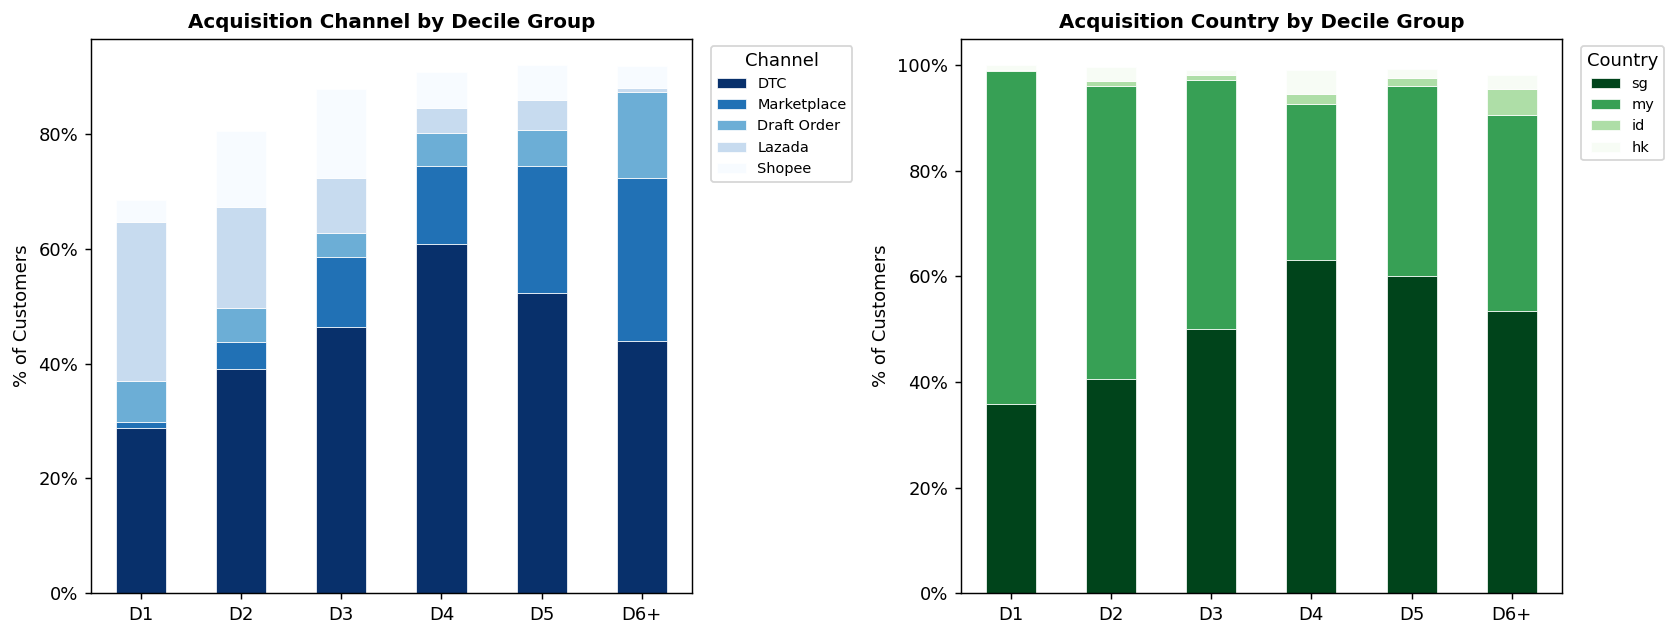

D2-D5 Channel distribution:
acquisition_channel
DTC            49.6
Marketplace    13.1
Shopee         10.3
Lazada          9.2
Draft Order     5.5
Other           5.2
POS             3.9
Email           2.9
Shop App        0.2
TikTok          0.1

D2-D5 Country distribution:
acquisition_country
sg    53.3
my    42.2
hk     2.6
id     1.2
jp     0.5
ph     0.1
au     0.0
gb     0.0
bn     0.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# --- Channel distribution by decile group ---
channel_ct = (
    profile.groupby(['decile_group', 'acquisition_channel'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
# Keep top channels
top_ch = profile['acquisition_channel'].value_counts().head(5).index.tolist()
if 'acquisition_channel' in channel_ct.columns:
    pass
channel_plot = channel_ct[[c for c in top_ch if c in channel_ct.columns]]
channel_plot = channel_plot.loc[['D1','D2','D3','D4','D5','D6+']]
channel_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Blues_r',
                  edgecolor='white', linewidth=0.4)
axes[0].set_title('Acquisition Channel by Decile Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('% of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Channel', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# --- Country distribution by decile group ---
country_ct = (
    profile.groupby(['decile_group', 'acquisition_country'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
top_co = profile['acquisition_country'].value_counts().head(4).index.tolist()
country_plot = country_ct[[c for c in top_co if c in country_ct.columns]]
country_plot = country_plot.loc[country_plot.index.isin(['D1','D2','D3','D4','D5','D6+'])]
country_plot = country_plot.reindex(['D1','D2','D3','D4','D5','D6+'])
country_plot.plot(kind='bar', stacked=True, ax=axes[1], colormap='Greens_r',
                  edgecolor='white', linewidth=0.4)
axes[1].set_title('Acquisition Country by Decile Group', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Customers')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Country', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'd2d5_channel_geo.png', dpi=130, bbox_inches='tight')
plt.show()

# Print D2-D5 summary
print('D2-D5 Channel distribution:')
print(d2d5['acquisition_channel'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('D2-D5 Country distribution:')
print(d2d5['acquisition_country'].value_counts(normalize=True).mul(100).round(1).to_string())

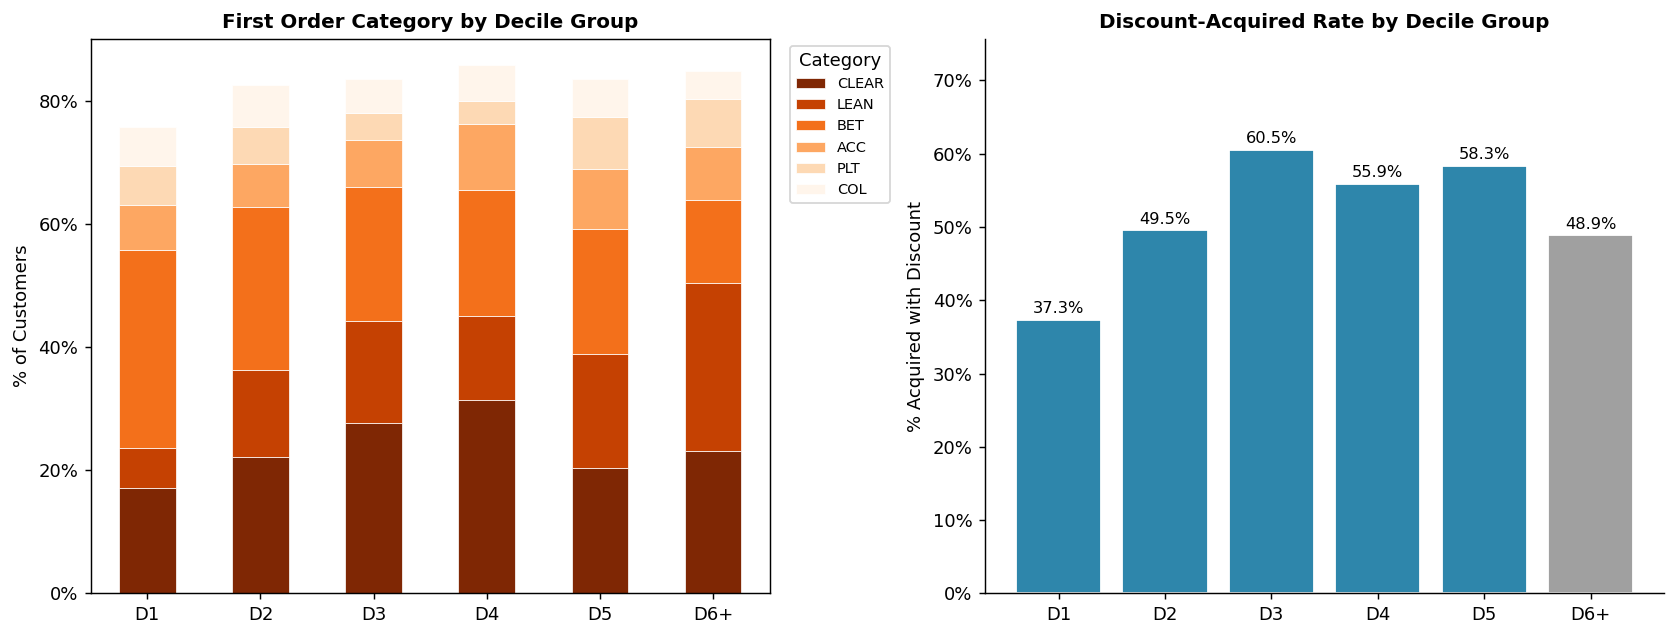

D2-D5 First category distribution:
first_order_top_category
CLEAR    25.5
BET      22.2
LEAN     15.7
ACC       8.8
COL       6.1
PLT       5.6
CAP       4.3
SOY       3.4
PRI       2.5
CRE       2.5
BND       2.3
ELT       1.0

D2-D5 Discount-acquired rate: 56.1%
D1 Discount-acquired rate: 37.3%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# --- First category by decile group ---
cat_ct = (
    profile.groupby(['decile_group', 'first_order_top_category'])
    .size().unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
top_cats = profile['first_order_top_category'].value_counts().head(6).index.tolist()
cat_plot = cat_ct[[c for c in top_cats if c in cat_ct.columns]]
cat_plot = cat_plot.reindex(['D1','D2','D3','D4','D5','D6+'])
cat_plot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Oranges_r',
              edgecolor='white', linewidth=0.4)
axes[0].set_title('First Order Category by Decile Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('% of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Category', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# --- Discount-acquired rate by decile group ---
disc_rate = (
    profile.groupby('decile_group')['is_discount_acquired']
    .mean().mul(100)
    .reindex(['D1','D2','D3','D4','D5','D6+'])
)
colors = ['#2E86AB' if d in ('D1','D2','D3','D4','D5') else '#A0A0A0' for d in disc_rate.index]
bars = axes[1].bar(disc_rate.index, disc_rate.values, color=colors, edgecolor='white')
for bar, val in zip(bars, disc_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Discount-Acquired Rate by Decile Group', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Acquired with Discount')
axes[1].set_ylim(0, disc_rate.max() * 1.25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'd2d5_category_discount.png', dpi=130, bbox_inches='tight')
plt.show()

print('D2-D5 First category distribution:')
print(d2d5['first_order_top_category'].value_counts(normalize=True).mul(100).round(1).to_string())
print()
print('D2-D5 Discount-acquired rate:', f"{d2d5['is_discount_acquired'].mean():.1%}")
print('D1 Discount-acquired rate:', f"{profile[profile['decile']=='D1']['is_discount_acquired'].mean():.1%}")

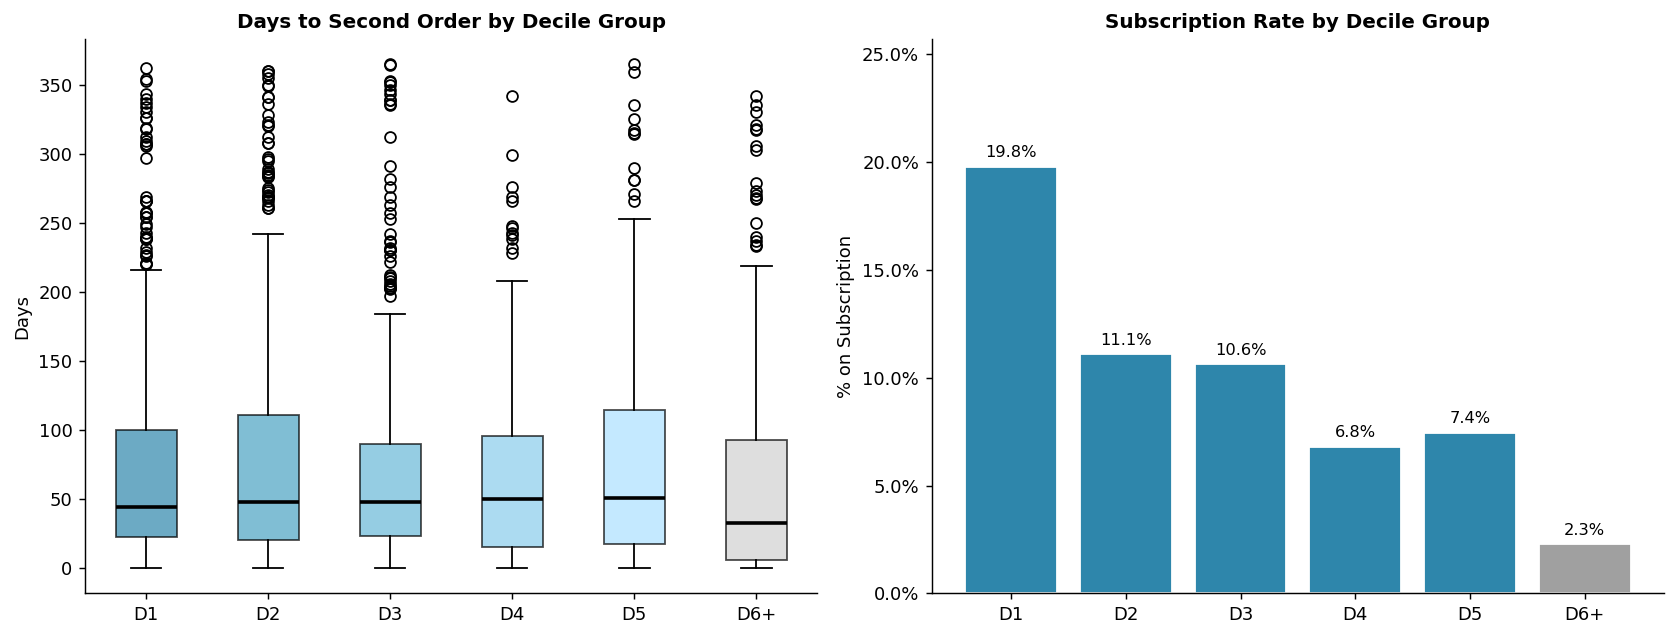

Median days to second order by decile group:
  D1: median=44d  n=550
  D2: median=48d  n=451
  D3: median=48d  n=351
  D4: median=50d  n=232
  D5: median=51d  n=164
  D6+: median=33d  n=296

D2-D5 Subscriber rate: 9.0%
D1 Subscriber rate: 19.8%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# --- Days to second order (for customers who made a second purchase) ---
repeaters = profile[profile['event_occurred'] == 1].copy()
repeaters_clean = repeaters[repeaters['days_to_second_order'].notna() &
                             (repeaters['days_to_second_order'] <= 365)]

d_groups = ['D1','D2','D3','D4','D5','D6+']
box_data = [repeaters_clean[repeaters_clean['decile_group']==d]['days_to_second_order'].dropna().values
            for d in d_groups]

bp = axes[0].boxplot(box_data, labels=d_groups, patch_artist=True,
                      medianprops={'color':'black','linewidth':2},
                      whiskerprops={'linewidth':1}, capprops={'linewidth':1})
colors_box = ['#2E86AB','#4BA3C3','#68B8D8','#89CCEC','#ABE0FF','#D0D0D0']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

axes[0].set_title('Days to Second Order by Decile Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Days')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Subscriber rate by decile group ---
sub_rate = (
    profile.groupby('decile_group')['is_subscriber']
    .mean().mul(100)
    .reindex(['D1','D2','D3','D4','D5','D6+'])
)
colors_sub = ['#2E86AB' if d in ('D1','D2','D3','D4','D5') else '#A0A0A0' for d in sub_rate.index]
bars2 = axes[1].bar(sub_rate.index, sub_rate.values, color=colors_sub, edgecolor='white')
for bar, val in zip(bars2, sub_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Subscription Rate by Decile Group', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% on Subscription')
axes[1].set_ylim(0, sub_rate.max() * 1.3)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'd2d5_timing_subscription.png', dpi=130, bbox_inches='tight')
plt.show()

print('Median days to second order by decile group:')
for d in d_groups:
    vals = repeaters_clean[repeaters_clean['decile_group']==d]['days_to_second_order'].dropna()
    if len(vals) > 0:
        print(f'  {d}: median={vals.median():.0f}d  n={len(vals)}')

print()
print('D2-D5 Subscriber rate:', f"{d2d5['is_subscriber'].mean():.1%}")
print('D1 Subscriber rate:', f"{profile[profile['decile']=='D1']['is_subscriber'].mean():.1%}")

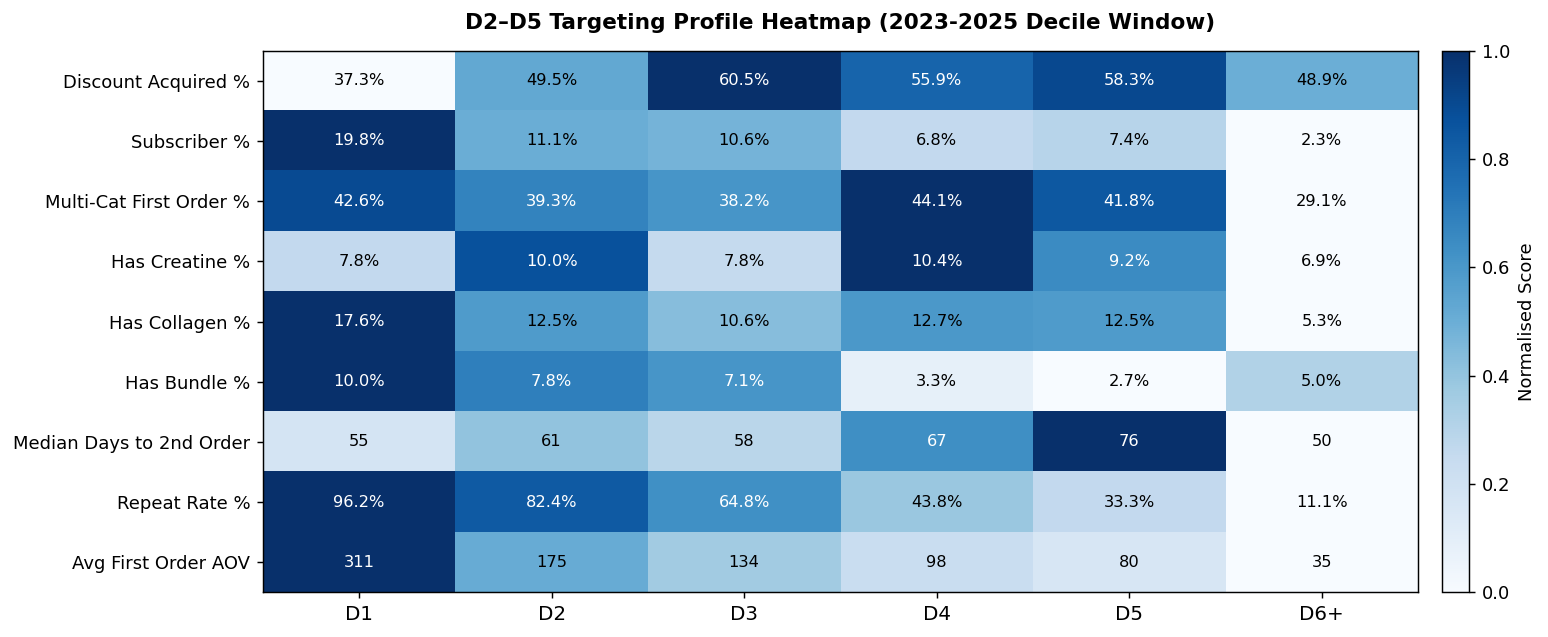

Profile summary:
     Discount Acquired %  Subscriber %  Multi-Cat First Order %  Has Creatine %  Has Collagen %  Has Bundle %  Median Days to 2nd Order  Repeat Rate %  Avg First Order AOV
D1                  37.3          19.8                     42.6             7.8            17.6          10.0                      55.0           96.2                310.7
D2                  49.5          11.1                     39.3            10.0            12.5           7.8                      61.0           82.4                175.2
D3                  60.5          10.6                     38.2             7.8            10.6           7.1                      58.0           64.8                134.2
D4                  55.9           6.8                     44.1            10.4            12.7           3.3                      67.0           43.8                 98.5
D5                  58.3           7.4                     41.8             9.2            12.5           2.7              

In [12]:
# Combined profile heatmap: D1 vs D2-D5 vs D6+ on key first-order signals
summary_rows = {}
for d in ['D1','D2','D3','D4','D5','D6+']:
    sub = profile[profile['decile_group'] == d]
    summary_rows[d] = {
        'Discount Acquired %': sub['is_discount_acquired'].mean() * 100,
        'Subscriber %': sub['is_subscriber'].mean() * 100,
        'Multi-Cat First Order %': sub['first_order_is_multi_category'].mean() * 100,
        'Has Creatine %': sub['first_order_has_cre'].mean() * 100,
        'Has Collagen %': sub['first_order_has_col'].mean() * 100,
        'Has Bundle %': sub['first_order_has_bnd'].mean() * 100,
        'Median Days to 2nd Order': sub['days_to_second_order'].median(),
        'Repeat Rate %': sub['event_occurred'].mean() * 100,
        'Avg First Order AOV': sub['first_order_aov'].mean(),
    }

heatmap_df = pd.DataFrame(summary_rows).T

# Normalise each column to 0-1 for colour scale
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5), dpi=130)
im = ax.imshow(heatmap_norm.T, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(heatmap_df)))
ax.set_xticklabels(heatmap_df.index, fontsize=11)
ax.set_yticks(range(len(heatmap_df.columns)))
ax.set_yticklabels(heatmap_df.columns, fontsize=10)

for i, row in enumerate(heatmap_df.index):
    for j, col in enumerate(heatmap_df.columns):
        val = heatmap_df.loc[row, col]
        fmt = f'{val:.0f}' if col in ('Median Days to 2nd Order','Avg First Order AOV') else f'{val:.1f}%'
        txt_color = 'white' if heatmap_norm.loc[row, col] > 0.6 else 'black'
        ax.text(i, j, fmt, ha='center', va='center', fontsize=9, color=txt_color)

ax.set_title('D2–D5 Targeting Profile Heatmap (2023-2025 Decile Window)',
             fontsize=12, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, label='Normalised Score', fraction=0.03, pad=0.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'd2d5_profile_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

print('Profile summary:')
print(heatmap_df.round(1).to_string())

---
## Part 3 — Cox Proportional Hazards Model

**Research question:** What first-order characteristics predict how quickly a customer makes a second purchase?

**Data:** All retail customers in `gold_churn_features`.
- `survival_duration` = days to second purchase (or observation window for censored customers)
- `event_occurred` = 1 if second purchase observed, 0 if censored (no repeat yet)

We fit a Cox PH model on the full population, then read off how D2–D5 covariates compare to D1.

> Note: D2–D5 customers all have `event_occurred=1` (they repeated by definition). This model estimates the *time to first repeat*, not the path from D2–D5 to D1. See Part 4 for D1 uplift.

In [13]:
if not LIFELINES_AVAILABLE:
    print('Install lifelines: pip install lifelines')
else:
    cox_cols = [
        'survival_duration', 'event_occurred',
        'is_discount_acquired', 'first_order_aov',
        'first_order_num_categories', 'first_order_is_multi_category',
        'first_order_has_cre', 'first_order_has_col',
        'first_order_has_bnd', 'first_order_has_protein',
        'is_subscriber',
        'acquisition_channel', 'acquisition_country',
    ]

    cox_data = profile.merge(
        cf[['customer_id','survival_duration','event_occurred']],
        on='customer_id', how='left', suffixes=('', '_cf')
    )
    # Use cf columns where profile ones may be stale
    for c in ['survival_duration','event_occurred']:
        if c+'_cf' in cox_data.columns:
            cox_data[c] = cox_data[c+'_cf'].combine_first(cox_data[c])
            cox_data.drop(columns=[c+'_cf'], inplace=True, errors='ignore')

    cox_input = profile[[
        'customer_id','survival_duration','event_occurred',
        'is_discount_acquired','first_order_aov','first_order_num_categories',
        'first_order_is_multi_category','first_order_has_cre','first_order_has_col',
        'first_order_has_bnd','first_order_has_protein','is_subscriber',
        'acquisition_channel','acquisition_country',
    ]].dropna(subset=['survival_duration','event_occurred'])

    # One-hot encode categorical variables
    cox_input = pd.get_dummies(
        cox_input,
        columns=['acquisition_channel','acquisition_country'],
        drop_first=True, dtype=float
    )

    # Drop customer_id before fitting
    cox_features = [c for c in cox_input.columns
                    if c not in ('customer_id','survival_duration','event_occurred')]

    cox_fit_df = cox_input[['survival_duration','event_occurred'] + cox_features].copy()
    cox_fit_df = cox_fit_df.replace([np.inf, -np.inf], np.nan).dropna()

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(cox_fit_df, duration_col='survival_duration', event_col='event_occurred',
            show_progress=False)

    print('Cox PH Model Summary (HR > 1 = faster repeat purchase):')
    print()
    cox_result = cph.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].copy()
    cox_result.columns = ['Hazard Ratio','HR Lower 95%','HR Upper 95%','p-value']
    cox_result = cox_result.sort_values('Hazard Ratio', ascending=False)
    print(cox_result.round(3).to_string())
    print()
    print(f'Concordance: {cph.concordance_index_:.3f}')

Cox PH Model Summary (HR > 1 = faster repeat purchase):

                                 Hazard Ratio  HR Lower 95%  HR Upper 95%  p-value
covariate                                                                         
acquisition_channel_Other               3.363         2.917         3.877    0.000
is_subscriber                           2.443         2.182         2.734    0.000
acquisition_country_gb                  2.371         0.337        16.670    0.385
acquisition_channel_Lazada              2.086         1.820         2.392    0.000
first_order_has_bnd                     1.392         1.191         1.627    0.000
acquisition_channel_Shop App            1.389         0.479         4.028    0.545
acquisition_channel_Shopee              1.202         1.006         1.437    0.043
first_order_has_cre                     1.134         0.984         1.308    0.083
first_order_has_col                     1.116         0.980         1.271    0.097
acquisition_country_my        

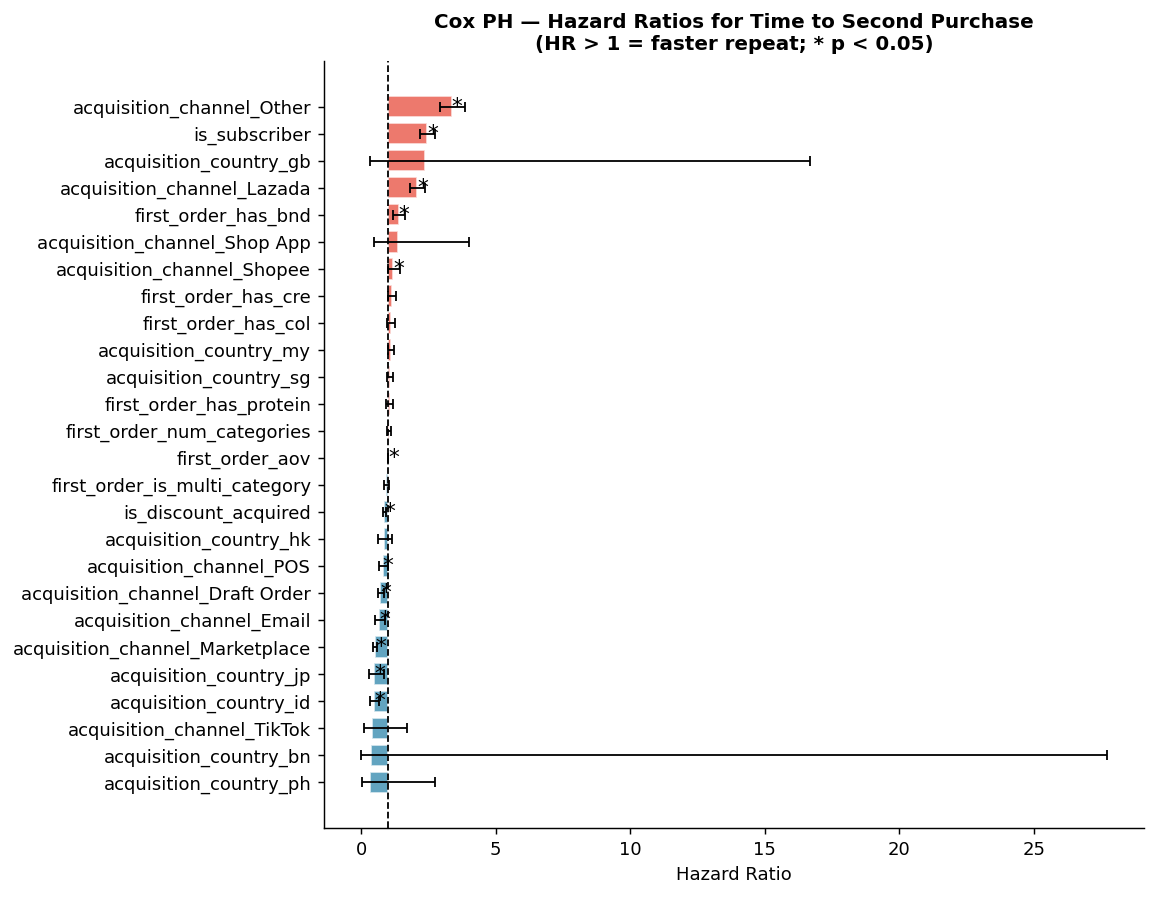

In [14]:
if LIFELINES_AVAILABLE:
    fig, ax = plt.subplots(figsize=(9, 7), dpi=130)
    cox_result.index.name = 'Feature'
    cox_plot = cox_result.copy().reset_index()
    cox_plot = cox_plot.sort_values('Hazard Ratio')

    colors_cox = ['#E74C3C' if hr > 1 else '#2E86AB' for hr in cox_plot['Hazard Ratio']]
    ax.barh(cox_plot['Feature'], cox_plot['Hazard Ratio'] - 1,
            left=1, color=colors_cox, alpha=0.75, edgecolor='white')
    ax.axvline(1, color='black', linewidth=1, linestyle='--')
    ax.errorbar(
        cox_plot['Hazard Ratio'], cox_plot['Feature'],
        xerr=[
            (cox_plot['Hazard Ratio'] - cox_plot['HR Lower 95%']).values,
            (cox_plot['HR Upper 95%'] - cox_plot['Hazard Ratio']).values
        ],
        fmt='none', color='black', capsize=3, linewidth=1
    )
    # Mark significant features
    for i, (_, row) in enumerate(cox_plot.iterrows()):
        if row['p-value'] < 0.05:
            ax.text(row['Hazard Ratio'] + 0.01, i, '*', fontsize=12, va='center', color='black')

    ax.set_title('Cox PH — Hazard Ratios for Time to Second Purchase\n(HR > 1 = faster repeat; * p < 0.05)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Hazard Ratio')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'd2d5_cox_forest.png', dpi=130, bbox_inches='tight')
    plt.show()

---
## Part 4 — D1 Uplift Analysis (Logistic Regression)

**Research question:** Among customers who are already in D2–D5, what first-order signals distinguish those who are closest to D1?

**Approach:** Logistic regression treating D1 vs D2–D5 as the binary outcome, using first-order features as predictors. Positive odds ratios point to traits that D1 customers have more often.

In [15]:
# Build binary dataset: D1 (label=1) vs D2-D5 (label=0)
d1_d2d5 = profile[profile['decile'].isin(['D1','D2','D3','D4','D5'])].copy()
d1_d2d5['is_d1'] = (d1_d2d5['decile'] == 'D1').astype(int)

lr_features = [
    'is_discount_acquired', 'first_order_aov', 'first_order_num_categories',
    'first_order_is_multi_category', 'first_order_has_cre', 'first_order_has_col',
    'first_order_has_bnd', 'first_order_has_protein', 'is_subscriber',
    'acquisition_channel', 'acquisition_country',
]

lr_data = pd.get_dummies(
    d1_d2d5[lr_features + ['is_d1']],
    columns=['acquisition_channel','acquisition_country'],
    drop_first=True, dtype=float
).dropna()

X_cols = [c for c in lr_data.columns if c != 'is_d1']
X = lr_data[X_cols].values
y = lr_data['is_d1'].values

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, C=0.5, solver='lbfgs'))
])
pipe.fit(X, y)

coefs = pipe.named_steps['lr'].coef_[0]
lr_result = pd.DataFrame({'Feature': X_cols, 'Coef': coefs})
lr_result['OddsRatio'] = np.exp(lr_result['Coef'])
lr_result = lr_result.sort_values('OddsRatio', ascending=False)

print('D1 vs D2-D5 Logistic Regression — Top predictors of D1 membership:')
print(lr_result.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print()
print(f'Class balance: D1={y.sum():,} ({y.mean():.1%}), D2-D5={(~y.astype(bool)).sum():,}')

D1 vs D2-D5 Logistic Regression — Top predictors of D1 membership:
                        Feature   Coef  OddsRatio
      acquisition_channel_Other  0.856      2.353
                first_order_aov  0.828      2.288
     acquisition_channel_Lazada  0.634      1.885
                  is_subscriber  0.381      1.464
acquisition_channel_Draft Order  0.335      1.398
      acquisition_channel_Email  0.223      1.249
         acquisition_country_sg  0.204      1.227
     acquisition_channel_Shopee  0.177      1.194
            first_order_has_bnd  0.152      1.164
            first_order_has_col  0.112      1.119
     first_order_num_categories  0.107      1.113
        first_order_has_protein  0.068      1.070
            first_order_has_cre -0.037      0.964
        acquisition_channel_POS -0.040      0.961
         acquisition_country_bn -0.053      0.948
         acquisition_country_gb -0.054      0.948
     acquisition_channel_TikTok -0.064      0.938
           is_discount_acquired -

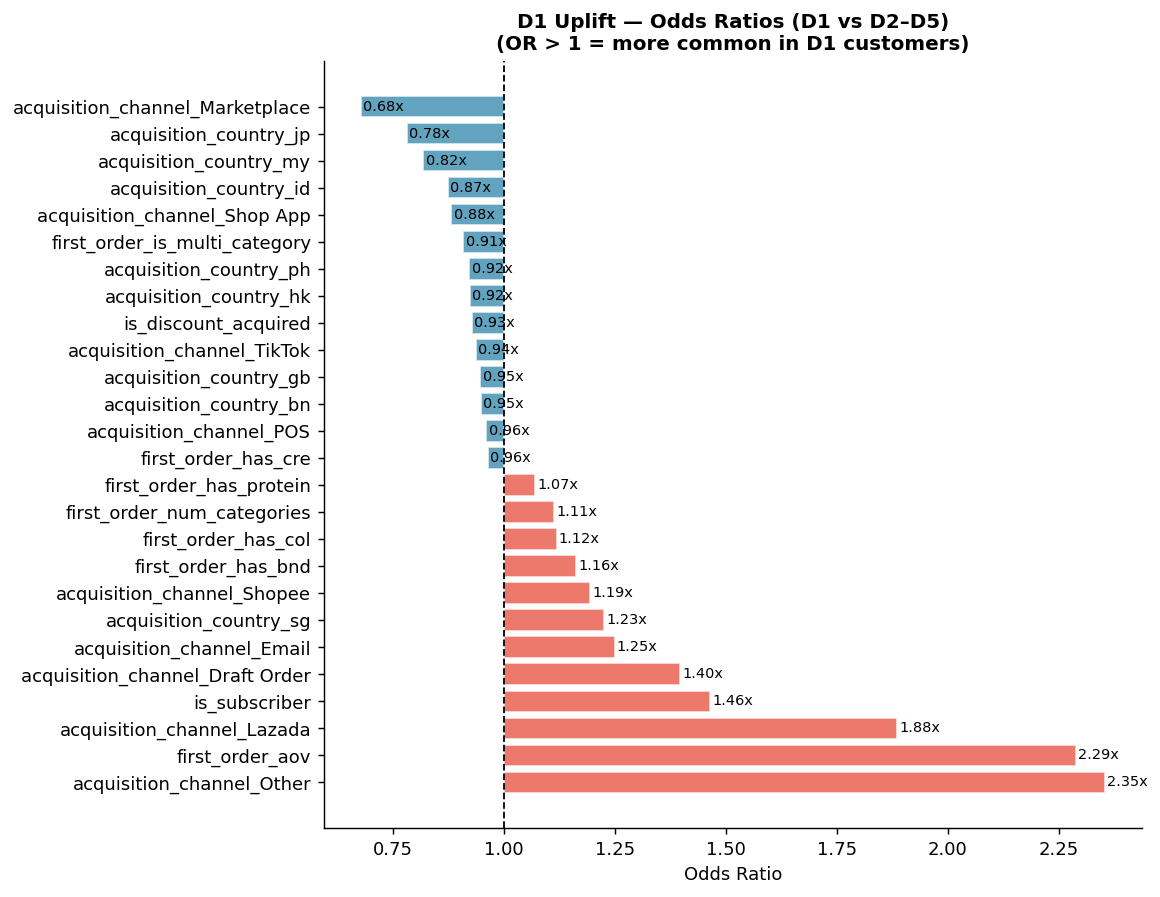

In [16]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=130)
plot_df = lr_result.copy()
colors_lr = ['#E74C3C' if or_>1 else '#2E86AB' for or_ in plot_df['OddsRatio']]

ax.barh(plot_df['Feature'], plot_df['OddsRatio'] - 1,
        left=1, color=colors_lr, alpha=0.75, edgecolor='white')
ax.axvline(1, color='black', linewidth=1, linestyle='--')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['OddsRatio'] + 0.005, i,
            f"{row['OddsRatio']:.2f}x",
            va='center', fontsize=8)

ax.set_title('D1 Uplift — Odds Ratios (D1 vs D2–D5)\n(OR > 1 = more common in D1 customers)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Odds Ratio')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'd2d5_d1_uplift_lr.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Part 5 — Targeting Recommendations

### Who are D2–D5?
The 'moveable middle' — customers with genuine repeat intent (AOF 2–4×) but not yet in the top revenue decile.
They represent a high-ROI targeting segment because:
- They've already demonstrated willingness to repurchase (repeat bias selected)
- They're not yet price-maximising (lower AOV/AOF than D1)
- They have room to grow across more categories or more frequent repurchase

### Signals that separate D1 from D2–D5 (from logistic regression)
| Signal | Interpretation | Action |
|---|---|---|
| Higher first-order AOV | D1 customers start with bigger baskets | Target D2-D5 customers whose first order was SGD 80+ with upsell campaigns |
| Multi-category first order | D1 customers explore more products from Day 1 | Promote bundle/starter packs to D2-D5 single-category customers |
| Creatine in first order | Cross-selling signal for committed fitness buyers | Run Creatine add-on promotions to D2-D5 non-CRE buyers |
| Subscription status | D1 customers subscribe at higher rates | Offer D2-D5 customers subscription trial after their 3rd order |
| Organic acquisition (no discount) | D1 customers were less discount-driven at acquisition | Reduce discount depth for D2-D5 re-engagement; test loyalty points instead |

### Priority targeting segments
1. **D2-D5 SG-DTC, organic, multi-category first order** → highest conversion probability to D1
2. **D2-D5 Shopee, discount-acquired, single category** → retention at risk; focus on habit formation (subscription trial)
3. **D2-D5 MY customers** → geography expansion opportunity; localised campaigns

### Caveats
- Deciles are assigned on 2023–2025 window revenue; customers active before 2023 who churned are underrepresented
- Cox model uses first-repeat survival only; not modelling D2→D1 transition directly
- Sample sizes for D1 vs D2-D5 logistic regression are imbalanced — interpret odds ratios directionally, not as causal